#  PCA y Clustering GMM Probabilístico
Reduce la dimensionalidad y agrupa los píxeles válidos en clases composicionales neutras. Evaluamos el número óptimo de clases $K$ mediante BIC.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from xrf.segmentation.xrf_gmm import Xrf_Gmm_Segmenter
from xrf.spatial.spatial_analyzer import Spatial_Analyzer
from xrf.config import Xrf_Segmentation_Config

In [3]:
# Project directory and data paths
PROJECT_DIR = Path.cwd()

# Find project root directory
while not (PROJECT_DIR / "src").exists():
    PROJECT_DIR = PROJECT_DIR.parent

# Data path
# Load raw data

DATA_DIR = PROJECT_DIR / "data" / "xrf"
RAW_DATA_DIR = DATA_DIR / "raw"
OUTPUT_DATA_DIR = DATA_DIR / "output"
FIGURES_DIR = OUTPUT_DATA_DIR / "figures"
DIAG_DIR = OUTPUT_DATA_DIR / "diagnostics"
PROCESSED_DATA_DIR = OUTPUT_DATA_DIR / "processed"

# CHECK IF FIGURES_DIR EXISTS, IF NOT CREATE IT
if not FIGURES_DIR.exists():
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)

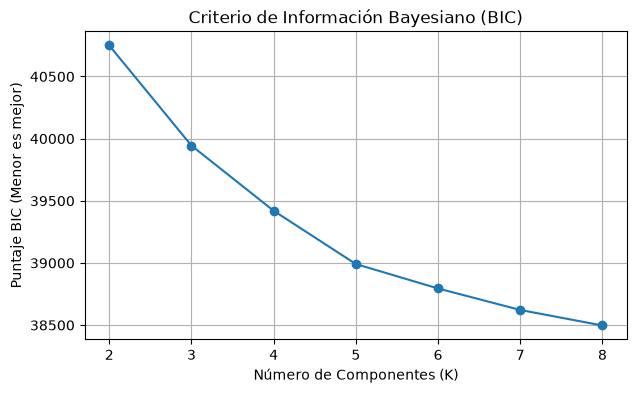

In [5]:
clr_data = np.load(PROCESSED_DATA_DIR / "page_001_clr.npy")
seg_config = Xrf_Segmentation_Config()
k_range = list(range(seg_config.Gmm_Min_K, seg_config.Gmm_Max_K + 1))

# Calcular curvas BIC
bic_scores = Xrf_Gmm_Segmenter.Compute_Bic_Curve(
    clr_data, K_Range=k_range, Variance_Ratio=seg_config.Pca_Variance_Ratio
)

plt.figure(figsize=(7, 4))
plt.plot(list(bic_scores.keys()), list(bic_scores.values()), marker="o")
plt.title("Criterio de Información Bayesiano (BIC)")
plt.xlabel("Número de Componentes (K)")
plt.ylabel("Puntaje BIC (Menor es mejor)")
plt.grid(True)
plt.show()

In [6]:
import json

# Elegir el K óptimo visualmente (ej. K=4)
optimal_k = 4
labels, probabilities, pca_model, gmm_model = Xrf_Gmm_Segmenter.Fit_Predict(
    clr_data,
    Num_Components=optimal_k,
    Variance_Ratio=seg_config.Pca_Variance_Ratio,
    Covariance_Type=seg_config.Covariance_Type,
)

# Cargar máscara del cuaderno 01 para reconstruir
mask = np.load(PROCESSED_DATA_DIR / "page_001_mask.npy")
class_map = Spatial_Analyzer.Reconstruct_Class_Map(labels, mask)

plt.figure(figsize=(6, 6))
plt.imshow(class_map, cmap="tab10", interpolation="nearest")
plt.title(f"Mapa de Clases XRF (K={optimal_k})")
plt.colorbar(label="Clase Asignada")
plt.show()

# Guardar los resultados para el cuaderno 04
np.save(PROCESSED_DATA_DIR / "page_001_labels.npy", labels)
np.save(PROCESSED_DATA_DIR / "page_001_class_map.npy", class_map)

# Guardar metadata (optimal_k)
with open(PROCESSED_DATA_DIR / "page_001_meta.json", "w") as f:
    json.dump({"optimal_k": optimal_k}, f)
print("Etiquetas, mapa de clases y metadatos exportados exitosamente.")

ValueError: NumPy boolean array indexing assignment cannot assign 5000 input values to the 9973 output values where the mask is true